In [87]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.data_utils import MoonsDataHelper
import warnings
warnings.filterwarnings("ignore")

## Data Visualization

In [88]:
x_train, x_test, y_train, y_test = MoonsDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1600, 2), (400, 2), (1600,), (400,))

In [89]:
x_train.head()

,Feature_1,Feature_2
1860,1.216889,-0.627630
353,1.216012,-0.401308
1333,-0.617450,1.005901
905,1.625030,-0.216752
1289,0.798015,0.056454


In [90]:
y_train.head()

1860    1
353     1
1333    0
905     1
1289    0
Name: Class_1, dtype: int64

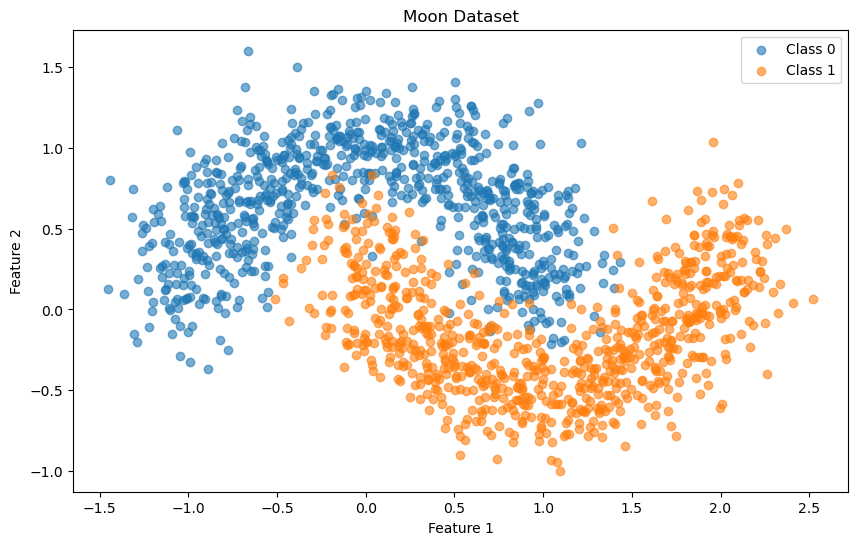

In [91]:
MoonsDataHelper.plot_moons(x_train, y_train)

## Model Training

In [92]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [93]:
n_features = x_train.shape[1]
weights = np.random.normal(0, np.sqrt(2.0 / n_features), size=(n_features))
bias = 0

weights.shape

(2,)

In [94]:
def sigmoid(linear):
    return 1 / (1 + np.exp(-linear))

In [95]:
def forward(x):
    linear = np.dot(x, weights) + bias
    return sigmoid(linear)

In [96]:
def compute_loss(y_true, prob):
    epsilon = 1e-15
    prob = np.clip(prob, epsilon, 1 - epsilon)
    loss = -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))
    return loss

In [97]:
def backward(x, prob, y_true, learning_rate=0.01):
    global weights, bias
    
    dw = x * (prob - y_true)
    db = prob - y_true
    
    weights -= dw * learning_rate
    bias -= db * learning_rate
    

In [98]:
epochs = 200
epoch_losses = []

learning_rate = 0.01

for epoch in range(epochs):
    total_loss = 0
    
    for idx in range(len(x_train)):
        prob = forward(x_train[idx])
        
        loss = compute_loss(y_train[idx], prob)
        total_loss += loss
        
        backward(x_train[idx], prob, y_train[idx], learning_rate)
    
    avg_loss = total_loss / len(x_train)

    epoch_losses.append(avg_loss)
    print(f"Epoch: {epoch + 1}/{epochs} | Avg. Loss: {avg_loss}")

Epoch: 1/200 | Avg. Loss: 0.6060196607314877
Epoch: 2/200 | Avg. Loss: 0.3479639871810811
Epoch: 3/200 | Avg. Loss: 0.3156023754168201
Epoch: 4/200 | Avg. Loss: 0.3015346992451496
Epoch: 5/200 | Avg. Loss: 0.29383242526315745
Epoch: 6/200 | Avg. Loss: 0.2892063687048183
Epoch: 7/200 | Avg. Loss: 0.2862733353968377
Epoch: 8/200 | Avg. Loss: 0.28434191409483817
Epoch: 9/200 | Avg. Loss: 0.2830332704802469
Epoch: 10/200 | Avg. Loss: 0.2821267307544419
Epoch: 11/200 | Avg. Loss: 0.2814876426108943
Epoch: 12/200 | Avg. Loss: 0.281030734819225
Epoch: 13/200 | Avg. Loss: 0.2807003453736759
Epoch: 14/200 | Avg. Loss: 0.2804592201401633
Epoch: 15/200 | Avg. Loss: 0.2802819020718057
Epoch: 16/200 | Avg. Loss: 0.280150691058315
Epoch: 17/200 | Avg. Loss: 0.2800530996467625
Epoch: 18/200 | Avg. Loss: 0.2799802088399181
Epoch: 19/200 | Avg. Loss: 0.27992558155453323
Epoch: 20/200 | Avg. Loss: 0.2798845305594318
Epoch: 21/200 | Avg. Loss: 0.27985361687182997
Epoch: 22/200 | Avg. Loss: 0.279830300981

In [99]:
def predict(x):
    prob = forward(x)
    return prob >= 0.5

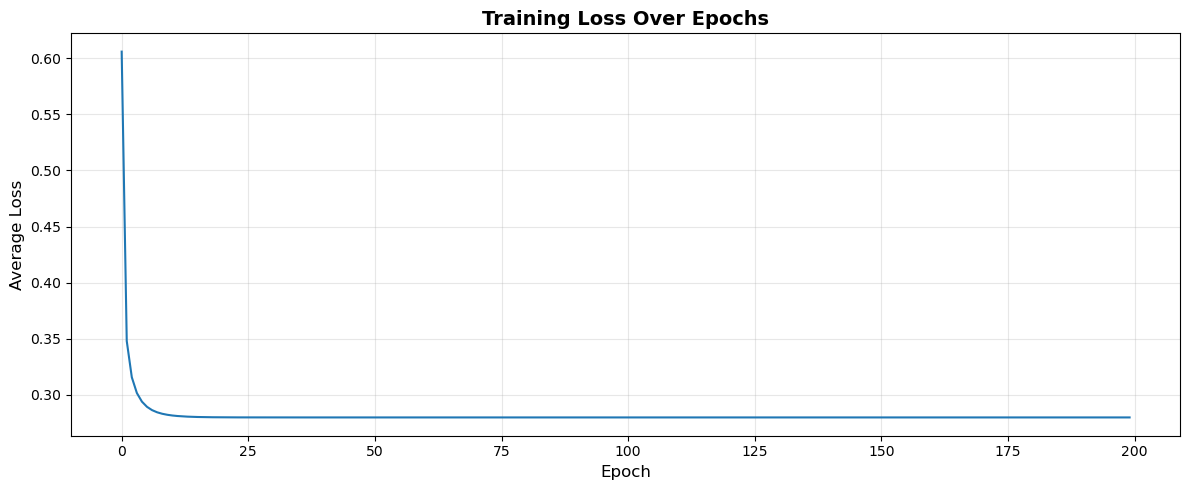

Initial loss: 0.606020
Final loss: 0.279760
Loss reduction: 53.84%


In [100]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(epoch_losses, linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Average Loss", fontsize=12)
ax.set_title("Training Loss Over Epochs", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {epoch_losses[0]:.6f}")
print(f"Final loss: {epoch_losses[-1]:.6f}")
print(f"Loss reduction: {(epoch_losses[0] - epoch_losses[-1])/epoch_losses[0]*100:.2f}%")

## Model Evaluation

In [101]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [102]:
predictions = []

for x in x_test:
    prediction = predict(x)
    predictions.append(prediction)

predictions = np.array(predictions)

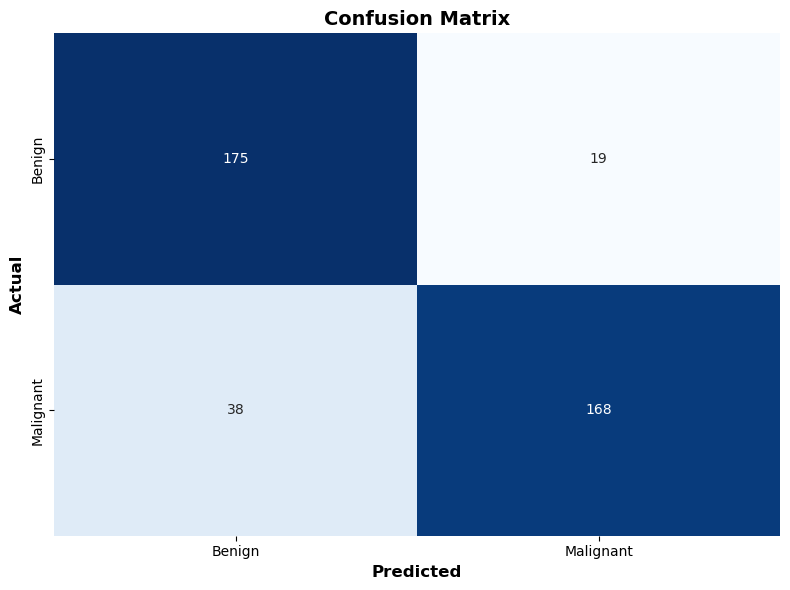

True Negatives: 175
False Positives: 19
False Negatives: 38
True Positives: 168

Sensitivity (Recall): 0.8155
Specificity: 0.9021
Precision: 0.8984
Accuracy: 0.8575
F1 Score: 0.8550


In [103]:
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
ax.set_xlabel("Predicted", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual", fontsize=12, fontweight="bold")
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

tn_val, fp_val, fn_val, tp_val = cm.ravel()
sensitivity = tp_val / (tp_val + fn_val)
specificity = tn_val / (tn_val + fp_val)
precision = tp_val / (tp_val + fp_val)
accuracy = (tp_val + tn_val) / (tp_val + tn_val + fp_val + fn_val)
f1_score = 2 * ((precision * sensitivity) / (precision + sensitivity))

print(f"True Negatives: {tn_val}")
print(f"False Positives: {fp_val}")
print(f"False Negatives: {fn_val}")
print(f"True Positives: {tp_val}")
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1_score:.4f}")

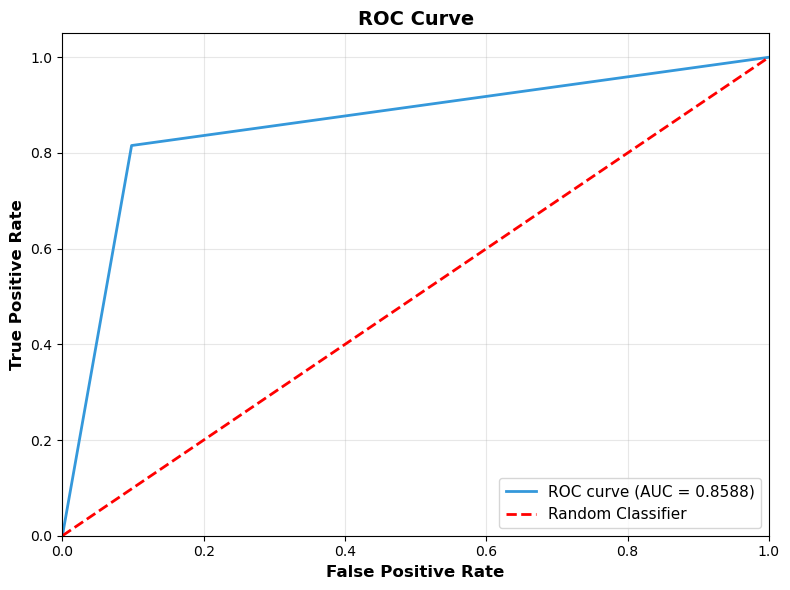

Area Under the Curve (AUC): 0.8588


In [104]:
fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#3498db", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
ax.set_title("ROC Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")

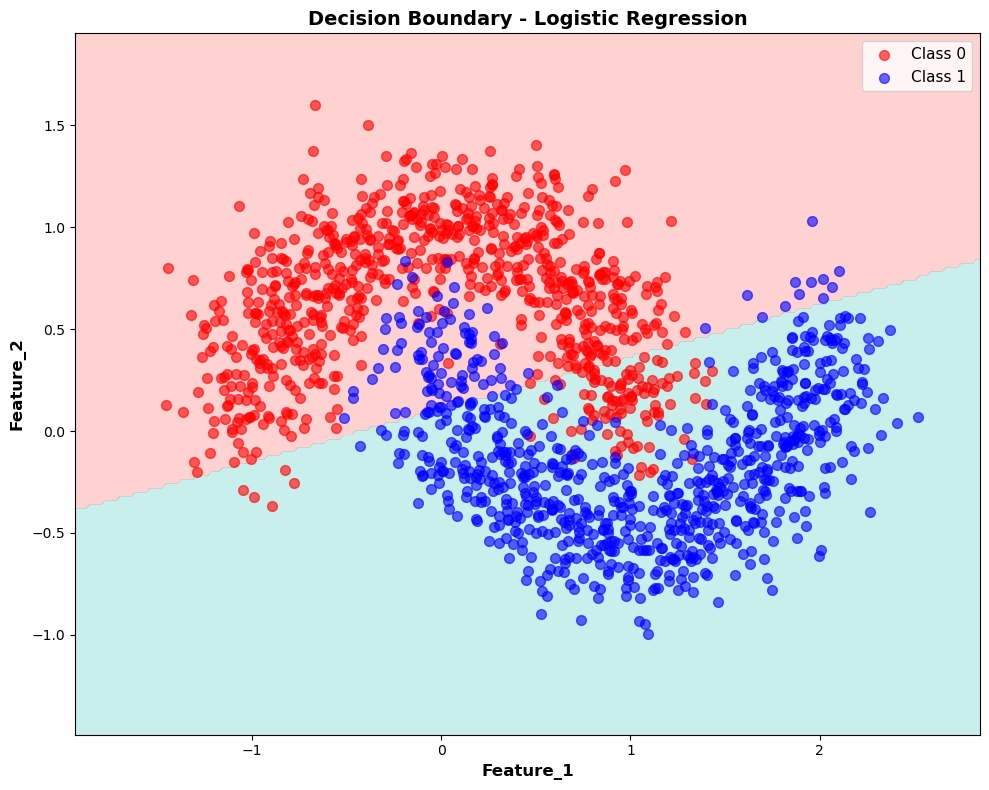

In [105]:
h = 0.02
x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = np.array([predict(np.array([xx[i, j], yy[i, j]]))
              for i in range(xx.shape[0]) for j in range(xx.shape[1])])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 0.5, 1], colors=['#FF6B6B', '#4ECDC4'])
ax.scatter(x_train[y_train == 0, 0], x_train[y_train == 0, 1], 
           c='red', marker='o', label='Class 0', alpha=0.6, s=50)
ax.scatter(x_train[y_train == 1, 0], x_train[y_train == 1, 1], 
           c='blue', marker='o', label='Class 1', alpha=0.6, s=50)
ax.set_xlabel('Feature_1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature_2', fontsize=12, fontweight='bold')
ax.set_title('Decision Boundary - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()